In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
df =  pd.read_csv("C:\\Users\Subhayan\Downloads\Synthetic.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Subhayan\AppData\Local\Temp\ipykernel_2876\2867216876.py:1: SyntaxWarning: invalid escape sequence '\S'
  df =  pd.read_csv("C:\\Users\Subhayan\Downloads\Synthetic.csv")


In [41]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values.reshape(-1, 1)
X = ((X - np.mean(X)) / np.std(X))
X = X.reshape(-1, 1)

In [55]:
def linear_function(X, theta):
    assert X.ndim > 1
    assert theta.ndim > 1
    return np.dot(X, theta)

def mean_squared_error(y_true, y_hat):
    return np.mean((y_true - y_hat)**2)

def initialize_theta(D):
    return np.zeros([D, 1])

def batch_gradient(X, y, theta):
    return -2.0*np.dot(X.T, (y - linear_function(X, theta)))

def update_function(theta, grads, step_size):
    return theta - step_size*grads

def per_sample_gradient(x_i, y_i, theta):
    return -2.0*x_i.T*(y_i - linear_function(x_i, theta))

def shuffle_data(X, y):
    n, _ = X.shape
    shuffled_idx = np.random.permutation(n)
    return X[shuffled_idx], y[shuffled_idx]

In [56]:
class Gradient_descent:

    def __init__(self):
        self.num_epochs = 10000
        self.learning_rate = 0.0001
        self.tolerance = 0.001
        self.losses = []
        pass

    def vanilla(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        _, d = X.shape
        self.theta = initialize_theta(d)
        self.losses = []
        for epoch in range(self.num_epochs):
            y_pred  = linear_function(X, self.theta)
            loss = mean_squared_error(y, y_pred)
            grads = batch_gradient(X, y, self.theta)
            self.theta = update_function(self.theta, grads, self.learning_rate)

            self.losses.append(loss)
        return self.theta, self.losses


    def stochastic(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        n, d = X.shape
        self.theta = initialize_theta(d)
        self.losses = []
        epoch = 0
        avg_loss = float('inf')
        while epoch < self.num_epochs and avg_loss > self.tolerance:
            running_loss = 0
            shuffled_x, shuffled_y = shuffle_data(X, y)
            for idx in range(shuffled_x.shape[0]):
                sample_x = shuffled_x[idx].reshape(1, -1)
                sample_y = shuffled_y[idx].reshape(1, -1)
                y_pred = linear_function(sample_x, self.theta)
                loss = mean_squared_error(sample_y, y_pred)
                running_loss += loss
                grads = per_sample_gradient(sample_x, sample_y, self.theta)
                self.theta = update_function(self.theta, grads, self.learning_rate)
            avg_loss = running_loss/n
            self.losses.append(avg_loss)
            epoch += 1
        return self.theta, self.losses


    def mini_batch(self, X, y, batch_size = 3):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        n, d = X.shape
        self.theta = initialize_theta(d)
        self.losses = []
        num_batches = n//batch_size
        X, y = shuffle_data(X, y)
        epoch = 0
        for epoch in range(self.num_epochs):
            running_loss = 0.0

            for batch_idx in range(0, n, batch_size):
                x_batch = X[batch_idx: batch_idx + batch_size]
                y_batch = y[batch_idx: batch_idx + batch_size]
                y_pred = linear_function(x_batch, self.theta)
                loss = mean_squared_error(y_batch, y_pred)
                grads = batch_gradient(x_batch, y_batch, self.theta)
                self.theta = update_function(self.theta, grads, self.learning_rate)
                running_loss += (loss*x_batch.shape[0])
            avg_loss = running_loss/n
            self.losses.append(avg_loss)
        return self.theta, self.losses

In [58]:
obj = Gradient_descent()
theta, losses = obj.mini_batch(X, y)
theta, losses

(array([[140.74868276],
        [ 85.15715544]]),
 [np.float64(26899.181940670103),
  np.float64(26367.924817713632),
  np.float64(25847.192138502272),
  np.float64(25336.775409752907),
  np.float64(24836.470268507594),
  np.float64(24346.076400310532),
  np.float64(23865.397459005788),
  np.float64(23394.240988123995),
  np.float64(22932.41834382635),
  np.float64(22479.744619375128),
  np.float64(22036.038571100435),
  np.float64(21601.122545833645),
  np.float64(21174.82240977832),
  np.float64(20756.96747879029),
  np.float64(20347.39045003888),
  np.float64(19945.92733502195),
  np.float64(19552.4173939079),
  np.float64(19166.703071178483),
  np.float64(18788.62993254643),
  np.float64(18418.046603122817),
  np.float64(18054.80470680937),
  np.float64(17698.75880689139),
  np.float64(17349.766347807585),
  np.float64(17007.68759807346),
  np.float64(16672.385594335363),
  np.float64(16343.726086532904),
  np.float64(16021.5774841477),
  np.float64(15705.810803516943),
  np.float6

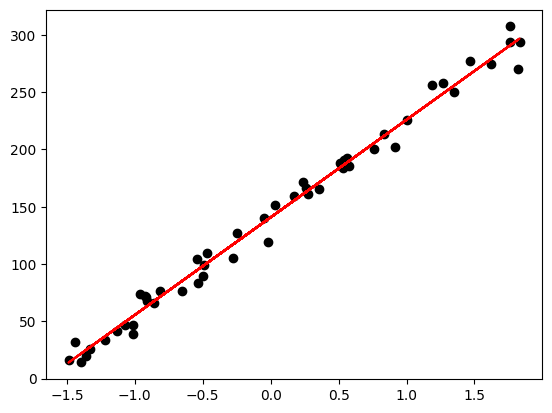

In [64]:
plt.scatter(X, y, color = 'black')
plt.plot(X, 140.74868276 + 85.15715544*X, color = 'red')
plt.show()